In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import mean_squared_error, r2_score

# -------------------------------
# Load Data
# -------------------------------
data = pd.read_csv("fbg_sensor_strain_temperature_data.csv")
X = data[["FBG1", "FBG2", "FBG3"]].values.astype(np.float32)
y_strain = data["Strain"].values.astype(np.float32)
y_temp = data["Temperature"].values.astype(np.float32)

# Train/test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_strain_train, y_strain_test = train_test_split(X, y_strain, test_size=0.2, random_state=42)
_, _, y_temp_train, y_temp_test = train_test_split(X, y_temp, test_size=0.2, random_state=42)

# -------------------------------
# PINN Model
# -------------------------------
def build_pinn():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(3,)),
        tf.keras.layers.Dense(32, activation='tanh'),
        tf.keras.layers.Dense(32, activation='tanh'),
        tf.keras.layers.Dense(1, activation='linear')
    ])
    return model

# Bragg equation constants (example values, replace with actual)
lambda_B0 = 1550.0  # nm
k_strain = 1.2e-3   # nm per microstrain
k_temp   = 1.0e-2   # nm per °C

def bragg_loss(y_true, y_pred, X, is_strain=True):
    # Fix shape mismatch here
    y_true = tf.expand_dims(y_true, -1)  # (batch, 1)
    
    # Data loss (MSE)
    mse = tf.reduce_mean(tf.square(y_true - y_pred))

    # Physics-informed loss: predicted wavelength shift vs. FBG input
    fbg_measured = tf.reduce_mean(X, axis=1, keepdims=True)  # mean FBG response
    if is_strain:
        lambda_pred = lambda_B0 + k_strain * y_pred  # predicted wavelength
    else:
        lambda_pred = lambda_B0 + k_temp * y_pred

    physics_loss = tf.reduce_mean(tf.square(lambda_pred - fbg_measured))

    return mse + 0.1 * physics_loss  # weight physics loss lightly

# -------------------------------
# Training Loop
# -------------------------------
def train_pinn(X_train, y_train, is_strain=True, epochs=200, lr=1e-3):
    model = build_pinn()
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

    for epoch in range(epochs):
        with tf.GradientTape() as tape:
            preds = model(X_train, training=True)
            loss = bragg_loss(y_train, preds, X_train, is_strain=is_strain)
        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))

        if epoch % 20 == 0:
            print(f"Epoch {epoch}: Loss = {loss.numpy():.6f}")

    return model

# -------------------------------
# Train for Strain and Temp
# -------------------------------
strain_model = train_pinn(X_train, y_strain_train, is_strain=True)
temp_model   = train_pinn(X_train, y_temp_train, is_strain=False)

# -------------------------------
# Evaluation
# -------------------------------
y_strain_pred = strain_model.predict(X_test)
y_temp_pred   = temp_model.predict(X_test)

print("\n--- Strain Model ---")
print("MSE:", mean_squared_error(y_strain_test, y_strain_pred))
print("R² :", r2_score(y_strain_test, y_strain_pred))

print("\n--- Temp Model ---")
print("MSE:", mean_squared_error(y_temp_test, y_temp_pred))
print("R² :", r2_score(y_temp_test, y_temp_pred))

Epoch 0: Loss = 240124.234375


Epoch 20: Loss = 240112.375000


Epoch 40: Loss = 240103.375000


Epoch 60: Loss = 240098.390625


Epoch 80: Loss = 240097.062500


...

1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 



--- Strain Model ---
MSE: 0.7766059637069702
R² : 0.7716088891029358

--- Temp Model ---
MSE: 2.241039752960205
R² : -0.03917539119720459



Residuals (Strain): mean = 0.09532628 std = 0.8760816
Residuals (Temp): mean = 1.4687817 std = 0.2893434


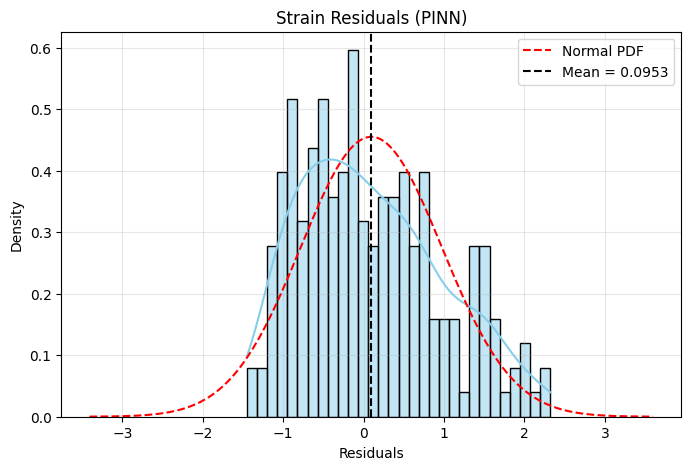

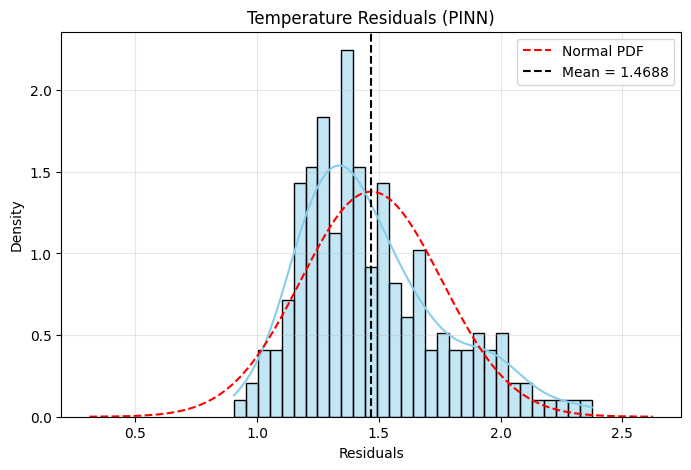

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# -------------------------------
# Residuals Calculation
# -------------------------------
residuals_strain = y_strain_test - y_strain_pred.flatten()
residuals_temp   = y_temp_test - y_temp_pred.flatten()

print("\nResiduals (Strain): mean =", np.mean(residuals_strain), "std =", np.std(residuals_strain))
print("Residuals (Temp): mean =", np.mean(residuals_temp), "std =", np.std(residuals_temp))

# -------------------------------
# Function to Plot Residual Histogram + KDE + Normal
# -------------------------------
def plot_residual_hist(residuals, title):
    plt.figure(figsize=(8, 5))
    
    # Histogram + KDE
    sns.histplot(residuals, bins=30, kde=True, stat="density", color="skyblue", edgecolor="black")
    
    # Normal distribution line
    mu, std = np.mean(residuals), np.std(residuals)
    x = np.linspace(mu - 4*std, mu + 4*std, 200)
    plt.plot(x, norm.pdf(x, mu, std), 'r--', label="Normal PDF")
    
    plt.axvline(mu, color="black", linestyle="--", label=f"Mean = {mu:.4f}")
    plt.title(f"{title} Residuals (PINN)")
    plt.xlabel("Residuals")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# -------------------------------
# Plot for Strain and Temp
# -------------------------------
plot_residual_hist(residuals_strain, "Strain")
plot_residual_hist(residuals_temp, "Temperature")




Combined Residuals: mean = 0.782054 std = 0.94721395


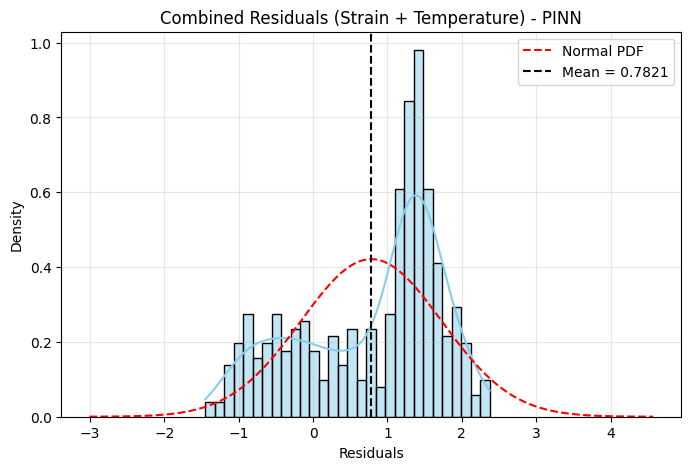

Combined MSE: 1.508823
Combined R²:  0.499541


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# ---------------------------------
# Combine Residuals (Strain + Temp)
# ---------------------------------
residuals_combined = np.concatenate([
    y_strain_test - y_strain_pred.flatten(),
    y_temp_test - y_temp_pred.flatten()
])

print("\nCombined Residuals: mean =", np.mean(residuals_combined), 
      "std =", np.std(residuals_combined))

# ---------------------------------
# Plot Combined Histogram + KDE + Normal
# ---------------------------------
plt.figure(figsize=(8, 5))

# Histogram + KDE
sns.histplot(residuals_combined, bins=30, kde=True, stat="density", 
             color="skyblue", edgecolor="black")

# Normal distribution line
mu, std = np.mean(residuals_combined), np.std(residuals_combined)
x = np.linspace(mu - 4*std, mu + 4*std, 200)
plt.plot(x, norm.pdf(x, mu, std), 'r--', label="Normal PDF")

# Vertical mean line
plt.axvline(mu, color="black", linestyle="--", label=f"Mean = {mu:.4f}")

# Formatting
plt.title("Combined Residuals (Strain + Temperature) - PINN")
plt.xlabel("Residuals")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
from sklearn.metrics import mean_squared_error, r2_score

# --------------------------
# Combine true and predicted
# --------------------------
y_combined_true = np.concatenate([y_strain_test, y_temp_test])
y_combined_pred = np.concatenate([y_strain_pred.flatten(), y_temp_pred.flatten()])

# --------------------------
# Compute Metrics
# --------------------------
mse_combined = mean_squared_error(y_combined_true, y_combined_pred)
r2_combined = r2_score(y_combined_true, y_combined_pred)

print(f"Combined MSE: {mse_combined:.6f}")
print(f"Combined R²:  {r2_combined:.6f}")



1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


Combined MSE: 0.012523
Combined R²:  0.995846


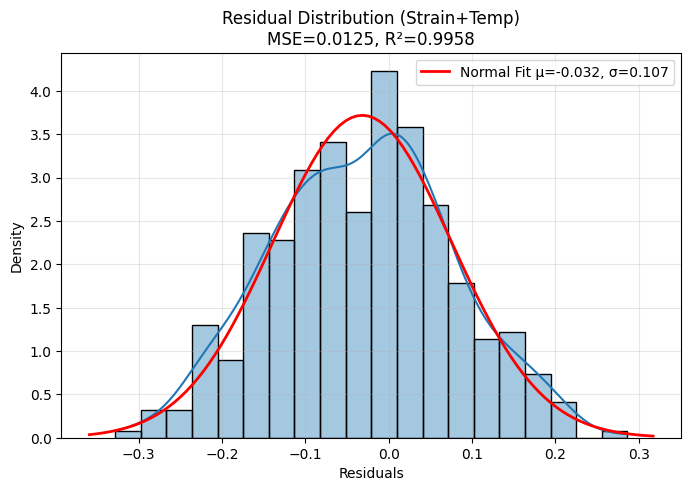

In [4]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# --------------------------
# Load your data
# --------------------------
# Replace with your actual CSV
import pandas as pd
data = pd.read_csv("fbg_sensor_strain_temperature_data.csv")

X = data[["FBG1", "FBG2", "FBG3"]].values
y_strain = data["Strain"].values
y_temp = data["Temperature"].values

# Combine strain + temp into one output
y_combined = np.column_stack([y_strain, y_temp])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_combined, test_size=0.2, random_state=42
)

# --------------------------
# Build ANN with regularization
# --------------------------
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3,)),
    tf.keras.layers.Dense(64, activation='relu',
                          kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    tf.keras.layers.Dense(32, activation='relu',
                          kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    tf.keras.layers.Dense(2)  # 2 outputs: strain + temperature
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='mse')

# --------------------------
# Train
# --------------------------
history = model.fit(X_train, y_train, epochs=200, batch_size=32,
                    validation_split=0.1, verbose=0)

# --------------------------
# Predict
# --------------------------
y_pred = model.predict(X_test)

# Residuals
residuals_combined = (y_test - y_pred).flatten()

# --------------------------
# Metrics
# --------------------------
y_combined_true = y_test.flatten()
y_combined_pred = y_pred.flatten()

mse_combined = mean_squared_error(y_combined_true, y_combined_pred)
r2_combined = r2_score(y_combined_true, y_combined_pred)

print(f"Combined MSE: {mse_combined:.6f}")
print(f"Combined R²:  {r2_combined:.6f}")

# --------------------------
# Residual Plot (with KDE + Normal curve)
# --------------------------
mu, std = norm.fit(residuals_combined)

plt.figure(figsize=(8, 5))
sns.histplot(residuals_combined, kde=True, stat="density", bins=20, alpha=0.4)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'r', linewidth=2, label=f"Normal Fit μ={mu:.3f}, σ={std:.3f}")
plt.title(f"Residual Distribution (Strain+Temp)\nMSE={mse_combined:.4f}, R²={r2_combined:.4f}")
plt.xlabel("Residuals")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
